In [19]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter, zoom

# Librerias recomendadas
from skimage.feature import peak_local_max
from photutils.centroids import centroid_quadratic

# Para lectura de archivos
from astropy.io import fits

warnings.simplefilter('ignore')

In [20]:
#Ruta de archivo
RUTA_FITS = r"C:\Users\santi\Downloads\M41\M41_wcs.fits"

In [21]:
def fotometria_apertura_numpy(img, xc, yc, r_ap=4.5, r_in=6.5, r_out=9.5):
    
    #Se crea una matriz que cubra la imagen
    h, w = img.shape #Extraer dimensiones de la imagen
    y, x = np.ogrid[:h, :w] #Crear matriz (ahorra RAM)
    
    #Ec 1 - Dist. Centro estrella
    dist2 = (x-xc)**2 + (y-yc)**2
    
    #Se define el radio de apertura arbitrariamente
    
    mask_ap= dist2 <= r_ap**2 #(Máscara Booleana)

    #nota: Se trabajan ambas variables al cuadrado

    #Máscara anillo
    
    mask_an = (dist2 >= r_in**2) & (dist2 <= r_out**2) #(Máscara Booleana)


    n_ap = np.count_nonzero(mask_ap) #conteo de pixeles apertura
    n_an = np.count_nonzero(mask_an) #conteo de pixeles anillo

    #omisión de cálculos con 0

    if n_an ==0 or n_ap == 0:
        return 0.0
    
    #calculo de flujo neto

    flujo_total= np.sum(img[mask_ap]) #Brillo de la estrella
    fondo_pixel= np.median(img[mask_an]) #Brillo del cielo

    flujo_neto= flujo_total - (fondo_pixel * n_ap)

    return flujo_neto if flujo_neto > 0 else 0.0 #Límites reales


### Ecuaciones

$$d^{2}= \Delta x^{2} + \Delta y^{2}  \tag{Ec. 1}$$

**Nota**: Se usa el cuadrado ya que es más eficiente que la raíz (computacionalmente).

$$r_{in}^2 \leq (x - x_c)^2 + (y - y_c)^2 \leq r_{out}^2 \tag{Ec. 2}$$

In [22]:
def motor_cuadratico_top(R,G,B):

    G_fondo= median_filter(G, size=40) #Filtro gaussiano en verde

    G_rest= G - G_fondo #imagen sin ruido

    std_G= np.std(G_rest) #Desviación estándar (sigma) - que tan ruidosa es la imagen limpia

    coords= peak_local_max(G_rest, min_distance=5, threshold_abs=5 * std_G) #coordenadas de las estrellas más brillantes
    

    #Top 30 estrellas más brillantes

    intensidades = G_rest[coords [:, 0], coords[:, 1]]  #comparación de intensidades

    idx_sort = np.argsort(intensidades)[::-1] #de más brillante a la más debil

    coords_ordenadas= coords[idx_sort]

    coords_out= []

    flujos_G, flujos_R, flujos_B = [], [], []

    print("[2/2] Refinando centroides para el Top 30...")

    box_r = 6 #13x13
    
    # Iterar sobre las detecciones hasta tener 30 válidas
    for cy, cx in coords_ordenadas:
        if len(coords_opt) >= 30: #para no exceder las 30 más brillantes
            break
            
        if box_r < cy < G.shape[0]-box_r and box_r < cx < G.shape[1]-box_r: #v. que la estrella no esté muy cerca del borde
            stamp = G_rest[cy-box_r:cy+box_r+1, cx-box_r:cx+box_r+1]  #recorte de la img
            
            try:
                # Ajuste Cuadrático 2D sobre el recorte
                xc_stamp, yc_stamp = centroid_quadratic(stamp)
                
                # Descartar si el ajuste matemático falló
                if np.isnan(xc_stamp) or np.isnan(yc_stamp):
                    continue
                
                # Convertir de coordenadas del recorte a "globales"
                x_fit = cx - box_r + xc_stamp
                y_fit = cy - box_r + yc_stamp
                
                # Fotometría matricial
                fG = fotometria_apertura_numpy(G, x_fit, y_fit)
                fR = fotometria_apertura_numpy(R, x_fit, y_fit)
                fB = fotometria_apertura_numpy(B, x_fit, y_fit)
                
                if fG > 0 and fR > 0 and fB > 0:
                    coords_opt.append([x_fit, y_fit])
                    flujos_G.append(fG)
                    flujos_R.append(fR)
                    flujos_B.append(fB)
            except Exception:
                continue
                
    coords_arr = np.array(coords_opt)
    mG = -2.5*np.log10(np.array(flujos_G)) + 25
    mR = -2.5*np.log10(np.array(flujos_R)) + 25
    mB = -2.5*np.log10(np.array(flujos_B)) + 25
    
    # Retornamos los colores solicitados: (B-R), (B-G), y (R-G)
    return coords_arr, mG, mB-mR, mB-mG, mR-mG

**Notas:**

``` min_distance=5 ```: Si encuentra dos picos a menos de 5 pixeles, ignora uno. Se usa para no encontrar 2 veces la misma estrella. 

```threshold_abs=5 * std_G```: Solo acepta picos de luz que midan al menos 5 veces el ruido promedio. Matemáticamente: $$Umbral=5 \sigma$$

### IMPLEMENTACIÓN DEL MÓDULO Y GRÁFICAS

[0/2] Demosaicing Bilineal (SciPy Zoom)...

[1/2] Detectando picos máximos con skimage (peak_local_max)...
[2/2] Refinando centros con centroid_quadratic (Photutils) para el Top 30...


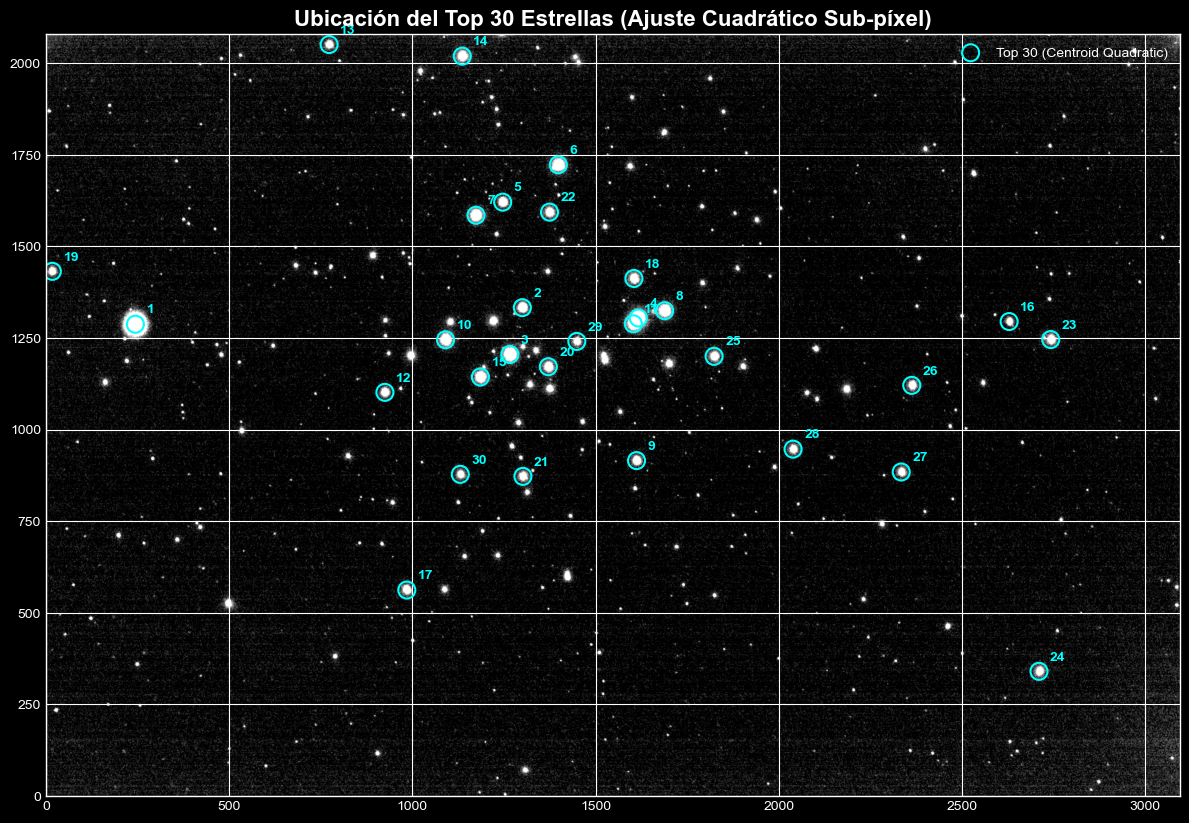


Generando Diagramas Color-Magnitud Instrumentales para las 30 estrellas encontradas.


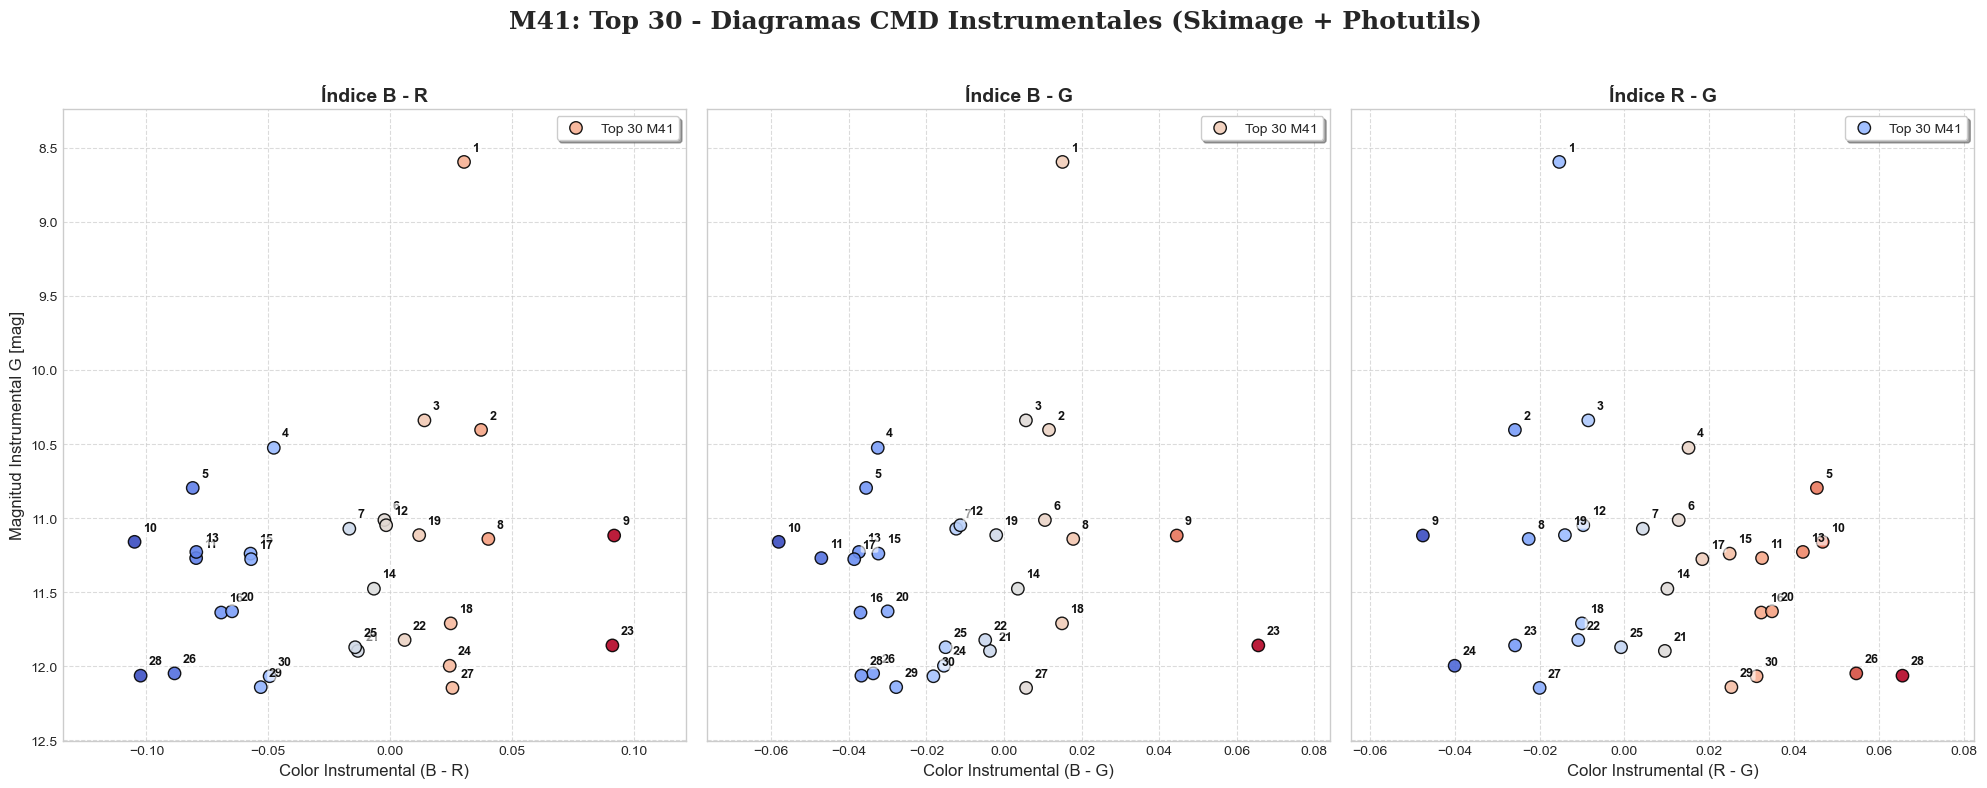

In [23]:
def ejecutar_pipeline_quadratic(ruta_f):
    # Lectura del FITS
    with fits.open(ruta_f) as hdul:
        data = hdul[0].data.astype(float)
        
    print("[0/2] Demosaicing Bilineal (SciPy Zoom)...")
    R_coarse, B_coarse = data[0::2, 0::2], data[1::2, 1::2]
    G_coarse = (data[0::2, 1::2] + data[1::2, 0::2]) / 2.0
    R, G, B = zoom(R_coarse, 2, order=1), zoom(G_coarse, 2, order=1), zoom(B_coarse, 2, order=1)

    # 1. Extraer Top 30
    pos_m, mG_m, br_m, bg_m, rg_m = motor_quadratic_top30(R, G, B)

    # GRÁFICA 1: Ubicación en el sensor
    plt.style.use('dark_background')
    fig1, ax1 = plt.subplots(figsize=(12, 10))
    norm = np.percentile(G, 99.5)
    ax1.imshow(G, cmap='gray', origin='lower', vmin=np.median(G), vmax=norm)
    ax1.scatter(pos_m[:, 0], pos_m[:, 1], s=150, edgecolors='cyan', facecolors='none', lw=1.5, label='Top 30 (Centroid Quadratic)')
    
    # Numerar las estrellas
    for i, (x, y) in enumerate(pos_m):
        ax1.annotate(str(i+1), (x, y), textcoords="offset points", xytext=(8, 8),
                     color='cyan', fontsize=10, fontweight='bold')
        
    ax1.set_title("Ubicación del Top 30 Estrellas (Ajuste Cuadrático Sub-píxel)", fontsize=16, fontweight='bold')
    ax1.legend()
    plt.tight_layout()
    plt.show()

    print(f"\nGenerando Diagramas Color-Magnitud Instrumentales para las {len(pos_m)} estrellas encontradas.")

    plots_cmd = [
        (br_m, "B - R", "royalblue"),
        (bg_m, "B - G", "teal"),
        (rg_m, "R - G", "crimson")
    ]

    # GRÁFICA 2: DIAGRAMAS CMD INSTRUMENTALES (B-R), (B-G), (R-G)
    # Usamos whitegrid para que el fondo sea más limpio
    plt.style.use('seaborn-v0_8-whitegrid')
    fig2, axs2 = plt.subplots(1, 3, figsize=(20, 8), sharey=True)
    fig2.suptitle("M41: Top 30 - Diagramas CMD Instrumentales (Skimage + Photutils)", fontsize=18, fontweight='bold', family='serif')

    # Calculamos los límites del Eje Y global para no cortar datos, y lo invertimos
    y_margin = (np.max(mG_m) - np.min(mG_m)) * 0.1
    y_lims = (np.max(mG_m) + y_margin, np.min(mG_m) - y_margin) 

    for i, (col_m, label, color) in enumerate(plots_cmd):
        
        # Puntos del Telescopio (Top 30)
        scatter = axs2[i].scatter(col_m, mG_m, s=80, c=col_m, cmap='coolwarm', 
                                  edgecolor='black', linewidth=1.0, alpha=0.9, zorder=3, label='Top 30 M41')
        
        # Etiquetas numéricas con Auto-Ajuste absoluto y caja blanca de contraste
        for j, (x, y) in enumerate(zip(col_m, mG_m)):
            axs2[i].annotate(str(j+1), (x, y), textcoords="offset points", xytext=(6, 6),
                             ha='left', va='bottom', fontsize=9, fontweight='bold', color='#111111',
                             bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.6, ec='none'),
                             zorder=4)

        # Márgenes dinámicos del Eje X
        x_margin = (np.max(col_m) - np.min(col_m)) * 0.15
        axs2[i].set_xlim(np.min(col_m) - x_margin, np.max(col_m) + x_margin)

        axs2[i].set_title(f"Índice {label}", fontweight='bold', fontsize=14)
        axs2[i].set_xlabel(f"Color Instrumental ({label})", fontsize=12)
        if i == 0: 
            axs2[i].set_ylabel("Magnitud Instrumental G [mag]", fontsize=12)
        
        axs2[i].grid(True, linestyle='--', alpha=0.7, zorder=0)
        axs2[i].legend(loc='best', frameon=True, shadow=True)
        
    # Aplicamos el límite invertido al eje Y compartido
    axs2[0].set_ylim(y_lims)
        
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    ejecutar_pipeline_quadratic(RUTA_FITS)